#### This assignment was created by Nezar Sheikhi 
#### Some parts of the code were generated with assistance from Grok and Perplexity AI.

1985-01-02 00:00:00 2024-12-30 00:00:00
Train set date range: 1985-03-28 00:00:00 to 2013-01-18 00:00:00
Validation set date range: 2013-01-22 00:00:00 to 2019-01-09 00:00:00
Test set date range: 2019-01-10 00:00:00 to 2024-12-30 00:00:00
Epoch 1/100


C:\Users\pette\AppData\Local\Temp\ipykernel_34108\2973792477.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0246 - val_loss: 0.0143
Epoch 2/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0046 - val_loss: 0.0054
Epoch 3/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 7.2648e-04 - val_loss: 0.0040
Epoch 4/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.0270e-04 - val_loss: 0.0013
Epoch 5/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.3760e-04 - val_loss: 0.0025
Epoch 6/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3183e-04 - val_loss: 0.0012
Epoch 7/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.3377e-04 - val_loss: 0.0016
Epoch 8/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1310e-04 - val_loss: 3.0793e-04
Epoch 9/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1292e-04 - val_loss: 5.1053e-04
Epoch 10/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.4078e-04 - val_loss: 3.7481e-04
Epoch 11/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8.4733e-05 - val_loss: 2.1547e-04
E

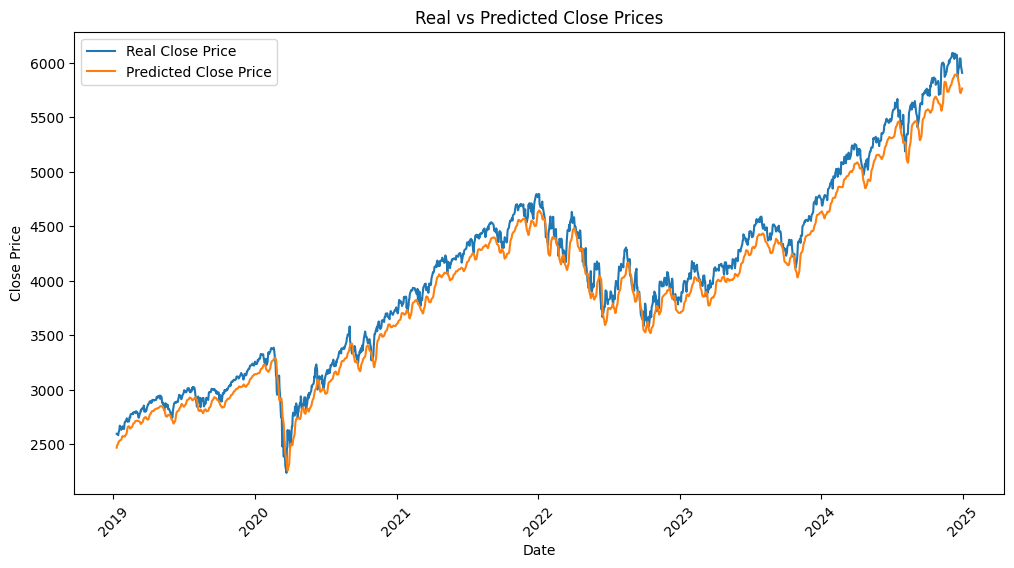

314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


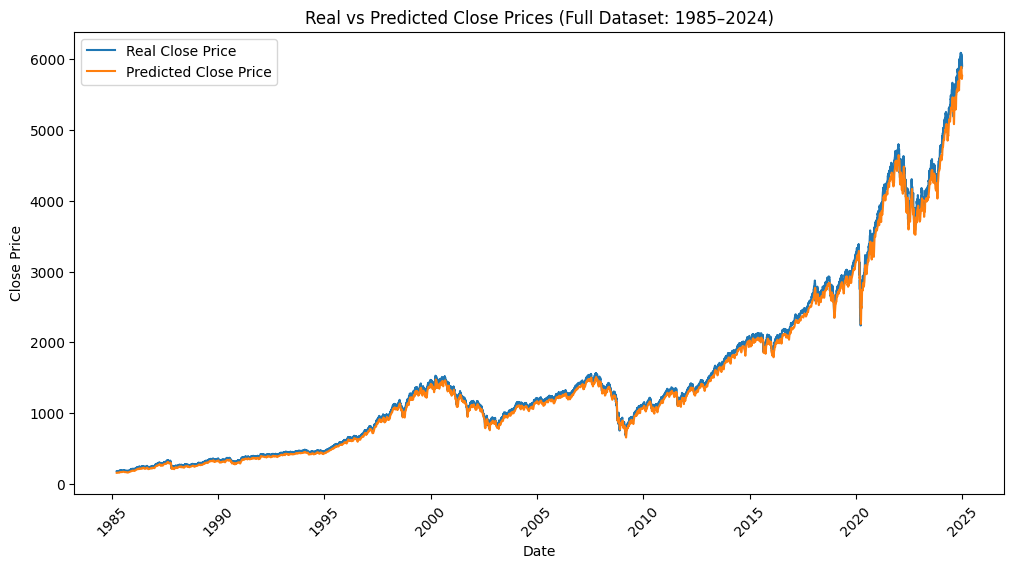

'\n\n# This code using all features as input variables.\nimport pandas as pd\nimport numpy as np\nfrom sklearn.preprocessing import MinMaxScaler\nfrom sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score\nimport matplotlib.pyplot as plt\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import SimpleRNN, Dense, Input\nfrom tensorflow.keras import regularizers\nimport matplotlib.dates as mdates\n\n# Load the data, skipping the first row and using the second row as header\nfile_path = \'sp500.xlsx\' # Update this with your actual file path\ndf = pd.read_excel(file_path, sheet_name=\'Sheet1\', header=1)\n\n# Rename columns for clarity\ndf.columns = [\'Date\', \'Close\', \'High\', \'Low\', \'Open\', \'Volume\', \'RSI\', \'MACD\', \'SMA_20\', \'SMA_50\', \'SMA_200\']\n\n# Strip any extra spaces in column names\ndf.columns = df.columns.str.strip()\n\n# Convert \'Date\' column to datetime\ndf[\'Date\'] = pd.to_datetime(df[\'Date\'], errors=\'coer

In [ ]:
#Authors: Nezar Sheikhi, Petter Rignell
# This code using just close as a target variable.
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras import regularizers
import matplotlib.dates as mdates

#Smape function from GeekForGeeks
def calculate_smape(actual, predicted) -> float:
    #Convert actual and predicted to numpy
    #array data type if not already
    if not all([isinstance(actual, np.ndarray), 
                isinstance(predicted, np.ndarray)]):
        actual, predicted = np.array(actual),
        np.array(predicted)

    return round(
        np.mean(
            np.abs(predicted - actual) / 
            ((np.abs(predicted) + np.abs(actual))/2)
        )*100, 2
    )

# Load the data, skipping the first row and using the second row as header
file_path = 'sp500.xlsx' # Update this with your actual file path
df = pd.read_excel(file_path, sheet_name='Sheet1', header=1)

# Rename columns for clarity
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'SMA_20', 'SMA_50', 'SMA_200']

# Strip any extra spaces in column names
df.columns = df.columns.str.strip()

# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows with invalid dates
df = df.dropna(subset=['Date'])

# Set 'Date' as the index
df.set_index('Date', inplace=True)

# Verify the range of the dates
print(df.index.min(), df.index.max())  # Should show the range from 1985 to 2024

# Use 'Close' as the target variable
data = df[['Close']]

# Normalize the data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Prepare sequences
SEQ_LENGTH = 60  # Use the last 60 days to predict the next day
def create_sequences(data, seq_length):
    X, y, indices = [], [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
        indices.append(i + seq_length)
    return np.array(X), np.array(y), np.array(indices)

X, y, indices = create_sequences(data_scaled, SEQ_LENGTH)

# Split into training (70%), validation (15%), and testing (15%)
train_split = int(0.70 * len(X))
val_split = int(0.85 * len(X))  # 70% + 15% = 85%
X_train, X_val, X_test = X[:train_split], X[train_split:val_split], X[val_split:]
y_train, y_val, y_test = y[:train_split], y[train_split:val_split], y[val_split:]
train_indices, val_indices, test_indices = indices[:train_split], indices[train_split:val_split], indices[val_split:]

# Verify date ranges
train_dates = df.index[train_indices]
val_dates = df.index[val_indices]
test_dates = df.index[test_indices]
print(f"Train set date range: {train_dates.min()} to {train_dates.max()}")
print(f"Validation set date range: {val_dates.min()} to {val_dates.max()}")
print(f"Test set date range: {test_dates.min()} to {test_dates.max()}")

# Build the SimpleRNN model
model = Sequential([
    Input(shape=(SEQ_LENGTH, 1)),
    SimpleRNN(50, activation='tanh', kernel_regularizer=regularizers.l2(0.01)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))

# Predict and inverse transform for all sets
predicted_train = model.predict(X_train)
predicted_val = model.predict(X_val)
predicted_test = model.predict(X_test)

predicted_train = scaler.inverse_transform(predicted_train)
y_train_original = scaler.inverse_transform(y_train)

predicted_val = scaler.inverse_transform(predicted_val)
y_val_original = scaler.inverse_transform(y_val)

predicted_test = scaler.inverse_transform(predicted_test)
y_test_original = scaler.inverse_transform(y_test)

# Calculate evaluation metrics for training set
train_rmse = np.sqrt(mean_squared_error(y_train_original, predicted_train))
train_smape = calculate_smape(y_train_original, predicted_train)
train_r2 = r2_score(y_train_original, predicted_train)

# Calculate evaluation metrics for validation set
val_rmse = np.sqrt(mean_squared_error(y_val_original, predicted_val))
val_smape = calculate_smape(y_val_original, predicted_val)
val_r2 = r2_score(y_val_original, predicted_val)

# Calculate evaluation metrics for test set
test_rmse = np.sqrt(mean_squared_error(y_test_original, predicted_test))
test_smape = calculate_smape(y_test_original, predicted_test)
test_r2 = r2_score(y_test_original, predicted_test)

# Print the evaluation metrics
print("Training Set Metrics:")
print(f"RMSE: {train_rmse:.4f}")
print(f"SMAPE: {train_smape:.4f}")
print(f"R^2: {train_r2:.4f}")
print("\nValidation Set Metrics:")
print(f"RMSE: {val_rmse:.4f}")
print(f"SMAPE: {val_smape:.4f}")
print(f"R^2: {val_r2:.4f}")
print("\nTest Set Metrics:")
print(f"RMSE: {test_rmse:.4f}")
print(f"SMAPE: {test_smape:.4f}")
print(f"R^2: {test_r2:.4f}")

# Plot real vs predicted with dates on the x-axis for test set
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_original, label='Real Close Price')
plt.plot(test_dates, predicted_test, label='Predicted Close Price')
plt.title('Real vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Plot predictions for the entire dataset (1985–2024)
predicted_all = model.predict(X)
predicted_all = scaler.inverse_transform(predicted_all)
y_all_original = scaler.inverse_transform(y)

plt.figure(figsize=(12, 6))
all_dates = df.index[indices]
plt.plot(all_dates, y_all_original, label='Real Close Price')
plt.plot(all_dates, predicted_all, label='Predicted Close Price')
plt.title('Real vs Predicted Close Prices (Full Dataset: 1985–2024)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))  # Show every 5 years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()
